In [12]:
import math
from itertools import cycle
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch

In [13]:
load_dir = Path("~/Data/foundata/out")
attributes = pl.read_csv(load_dir / "all_attributes.csv")
trips = pl.read_csv(load_dir / "all_trips.csv")
attributes.head()

hid,pid,age,hh_size,hh_income,sex,dwelling,ownership,vehicles,disability,education,can_wfh,occupation,race,has_licence,relationship,employment,country,source,year,month,day,rurality,weight
str,str,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,f64
"""ltds24127231""","""ltds2412723104""",3,4,129983,"""male""","""unknown""","""unknown""",1,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""saturday""","""suburban""",888.083537
"""ltds24057183""","""ltds2405718303""",1,3,null,"""male""","""unknown""","""unknown""",0,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""saturday""","""suburban""",1389.686246
"""ltds24261191""","""ltds2426119103""",0,3,73786,"""female""","""unknown""","""unknown""",1,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""wednesday""","""suburban""",573.793877
"""ltds24392111""","""ltds2439211107""",2,7,183486,"""female""","""unknown""","""unknown""",2,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""other""","""student""","""uk""","""ltds""",2024,null,"""tuesday""","""suburban""",490.465951
"""ltds24295273""","""ltds2429527302""",2,2,null,"""female""","""unknown""","""unknown""",0,"""unknown""","""unknown""","""n/a""","""n/a""","""unknown""","""no""","""child""","""student""","""uk""","""ltds""",2024,null,"""monday""","""urban""",1394.780525


In [14]:
import polars as pl

# trips already joined with attributes so that trips["source"] exists
trips = trips.join(attributes.select("pid", "source"), on="pid", how="left")

# trip counts per source
trip_counts = trips.group_by("source").agg(n_trips=pl.len())

# attribute counts per source
attribute_counts = attributes.group_by("source").agg(n_attributes=pl.len())

# join them together
attributes_summary = attribute_counts.join(
    trip_counts, on="source", how="left"
).fill_null(0)

# add total row
total_row = pl.DataFrame(
    {
        "source": ["total"],
        "n_attributes": [attributes.height],
        "n_trips": [trips.height],
    },
    schema={
        "source": pl.String,
        "n_attributes": pl.UInt32,
        "n_trips": pl.UInt32,
    },
)

attributes_summary = pl.concat([attributes_summary, total_row], how="diagonal")

print(attributes_summary)

shape: (7, 3)
┌────────┬──────────────┬─────────┐
│ source ┆ n_attributes ┆ n_trips │
│ ---    ┆ ---          ┆ ---     │
│ str    ┆ u32          ┆ u32     │
╞════════╪══════════════╪═════════╡
│ qhts   ┆ 51481        ┆ 126485  │
│ vista  ┆ 94821        ┆ 257557  │
│ cmap   ┆ 31540        ┆ 101965  │
│ nts    ┆ 1728067      ┆ 5106905 │
│ nhts   ┆ 716376       ┆ 2604832 │
│ ltds   ┆ 71734        ┆ 137900  │
│ total  ┆ 2694019      ┆ 8465280 │
└────────┴──────────────┴─────────┘


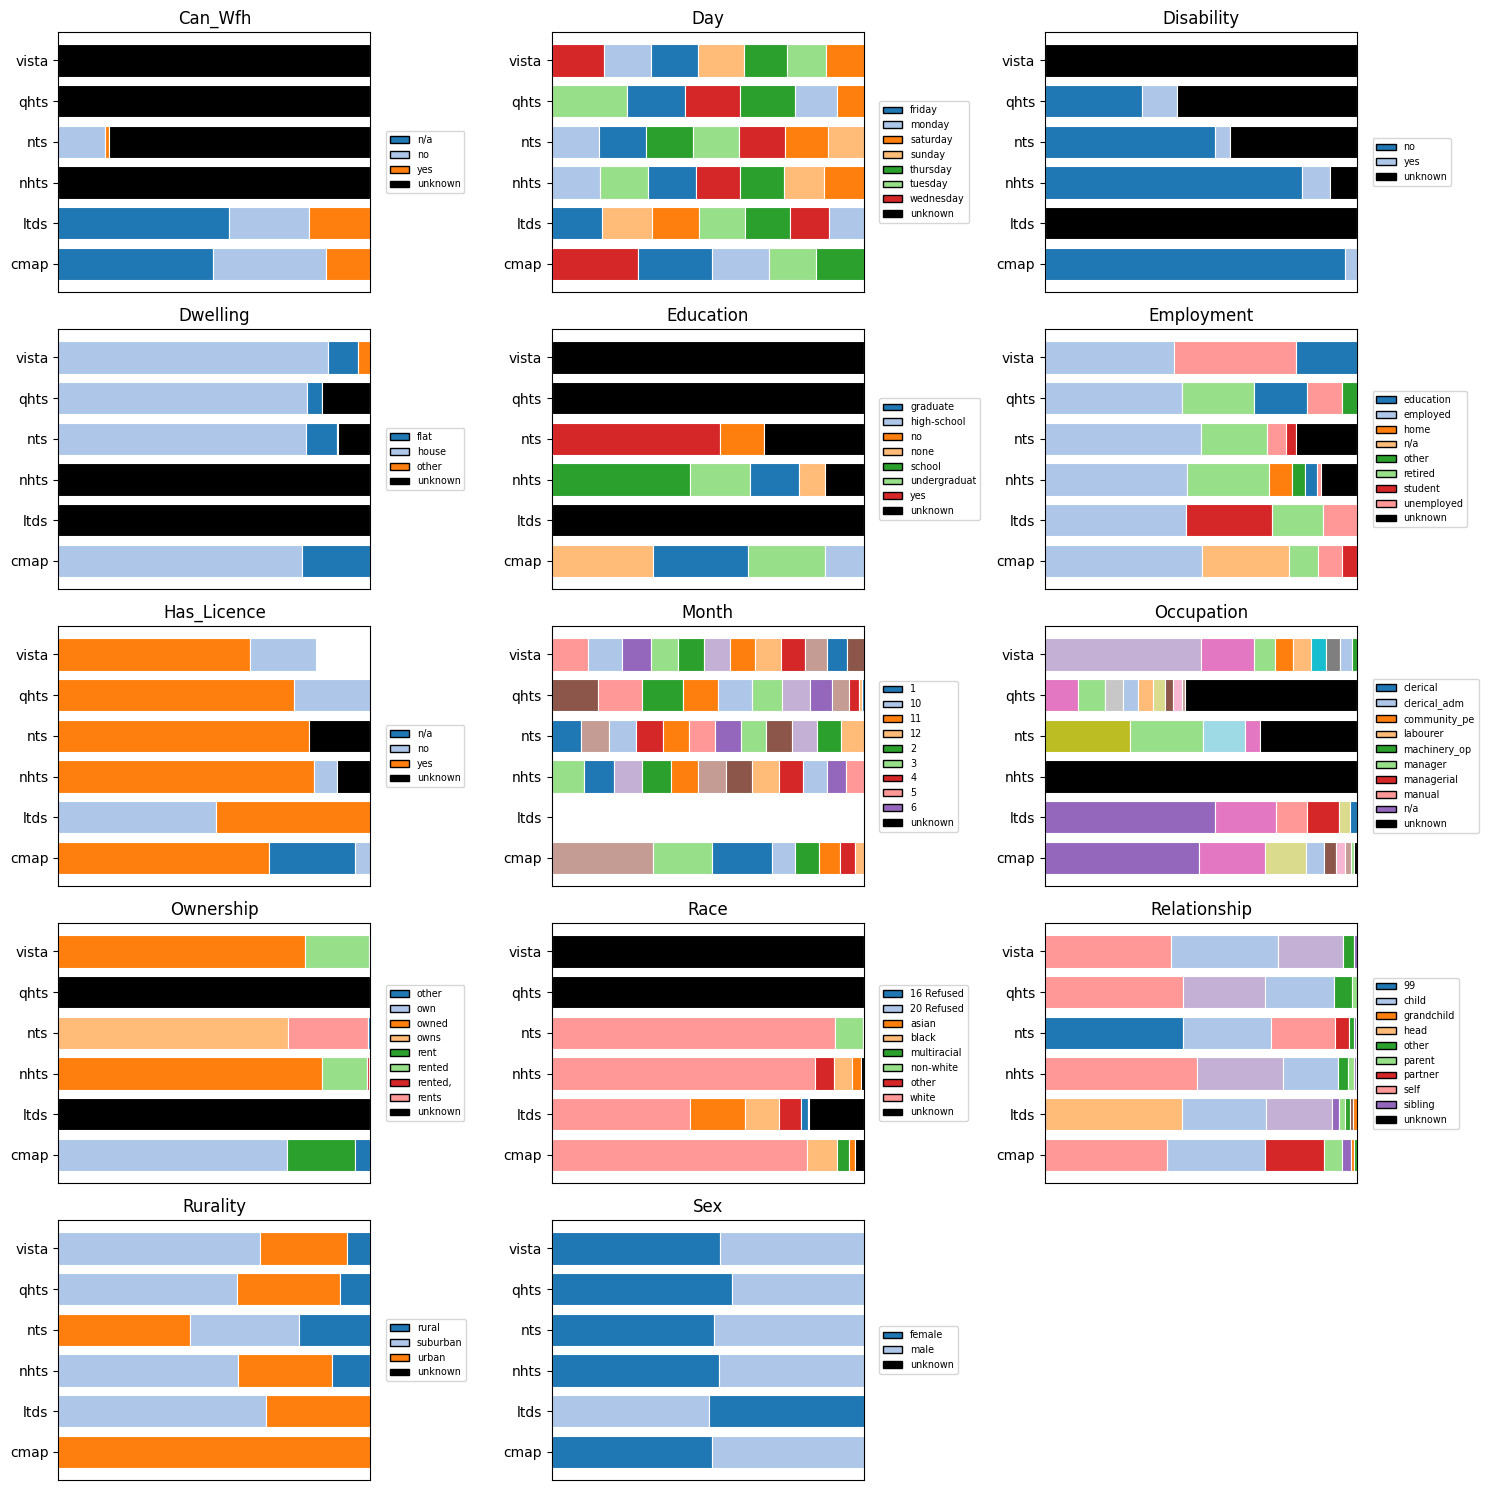

In [ ]:
# ---------------------------------------------
# Select categorical columns (excluding id/meta)
# ---------------------------------------------
cat_cols = {
    col for col in attributes.columns if attributes[col].dtype == pl.String
} - {"source", "pid", "hid", "country"}

# ---------------------------------------------
# Grid layout
# ---------------------------------------------
n_cols = 3
n_plots = len(cat_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(5 * n_cols, 3.0 * n_rows), squeeze=False
)

# ---------------------------------------------
# Sample once for consistency
# ---------------------------------------------
if attributes.height > 10_000:
    df_plot = attributes.sample(n=10_000, shuffle=True)
else:
    df_plot = attributes


# ---------------------------------------------
# Helper: build consistent color map
# ---------------------------------------------
def build_color_map_for_column(
    df: pl.DataFrame, col: str, cmap_name: str = "tab20"
):
    uniques = df.select(pl.col(col)).drop_nulls().unique().to_series().to_list()

    non_unknown = sorted(v for v in uniques if str(v).lower() != "unknown")

    cmap = plt.get_cmap(cmap_name)
    if hasattr(cmap, "colors") and cmap.colors is not None:
        palette = list(cmap.colors)
    else:
        palette = [cmap(i / 20) for i in range(20)]

    color_cycle = cycle(palette)
    return {v: next(color_cycle) for v in non_unknown}


# ---------------------------------------------
# Plot one column + legend
# ---------------------------------------------
def plot_column(ax, df: pl.DataFrame, col: str, on: str):

    groups = df.select(pl.col(on)).drop_nulls().unique().to_series().to_list()
    groups = sorted(groups)

    color_map = build_color_map_for_column(df, col)

    for i, g in enumerate(groups):
        sub = df.filter(pl.col(on) == g)
        proportions = (
            sub[col]
            .value_counts(normalize=True)
            .sort("proportion", descending=True)
        )

        unknown = proportions.filter(
            pl.col(col).cast(pl.Utf8).str.to_lowercase() == "unknown"
        )
        other = proportions.filter(
            pl.col(col).cast(pl.Utf8).str.to_lowercase() != "unknown"
        )

        proportions = other.vstack(unknown)

        left = 0.0
        for val, prop in proportions.select(col, "proportion").iter_rows():
            if val is None:
                continue

            color = (
                "black"
                if str(val).lower() == "unknown"
                else color_map.get(val, "#999999")
            )

            ax.barh(
                y=i,
                width=float(prop),
                left=left,
                color=color,
                edgecolor="white",
                linewidth=0.8,
            )
            left += float(prop)

    ax.set_title(col.title())
    ax.set_yticks(range(len(groups)))
    ax.set_yticklabels(groups)
    ax.set_xticks([])
    ax.set_xlim(0, 1)

    # -----------------------------------------
    # Add legend to the right of the subplot
    # -----------------------------------------
    legend_items = []

    # Non-unknown categories
    for i, (cat, color) in enumerate(color_map.items()):
        label = str(cat)
        label_length = min(12, len(label))
        legend_items.append(
            Patch(
                facecolor=color, edgecolor="black", label=label[:label_length]
            )
        )
        if i >= 8:
            break  # Limit to 9 categories for readability

    # Always add unknown as black
    legend_items.append(
        Patch(facecolor="black", edgecolor="black", label="unknown")
    )

    ax.legend(
        handles=legend_items,
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        borderaxespad=0.0,
        fontsize="x-small",
    )


# ---------------------------------------------
# Render each subplot
# ---------------------------------------------
for idx, col in enumerate(sorted(cat_cols)):
    r = idx // n_cols
    c = idx % n_cols
    ax = axes[r][c]

    plot_column(ax, df_plot, col, on="source")

# Remove empty axes
for i in range(n_plots, n_rows * n_cols):
    r = i // n_cols
    c = i % n_cols
    axes[r][c].axis("off")

plt.tight_layout()
plt.show()